<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Test Environment for Generative AI classroom labs

This lab provides a test environment for the codes generated using the Generative AI classroom.

Follow the instructions below to set up this environment for further use.


# Setup


### Install required libraries

In case of a requirement of installing certain python libraries for use in your task, you may do so as shown below.


In [1]:
%pip install seaborn
import piplite

await piplite.install(['nbformat', 'plotly'])

### Dataset URL from the GenAI lab
Use the URL provided in the GenAI lab in the cell below. 


In [96]:
# URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv"


In [3]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"


### 
Downloading the dataset

Execute the following code to download the dataset in to the interface.

> Please note that this step is essential in JupyterLite. If you are using a downloaded version of this notebook and running it on JupyterLabs, then you can skip this step and directly use the URL in pandas.read_csv() function to read the dataset as a dataframe


In [5]:
from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

path = URL

await download(path, "dataset.csv")
file_name  = "dataset.csv"

---


# Test Environment


In [13]:
# Keep appending the code generated to this cell, or add more cells below this to execute in parts
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv(file_name, header=0)
df.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
0,Fiesta,2017,Automatic,15944,Petrol,150.0,57.7,1.0,12000
1,Focus,2018,Manual,9083,Petrol,150.0,57.7,1.0,14000
2,Focus,2017,Manual,12456,Petrol,150.0,57.7,1.0,13000
3,Fiesta,2019,Manual,10460,Petrol,145.0,40.3,1.5,17500
4,Fiesta,2019,Automatic,1482,Petrol,145.0,48.7,1.0,16500


In [14]:
df.describe()

,year,mileage,tax,mpg,engineSize,price
count,17966.000000,17966.000000,17963.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,23362.608761,113.329177,57.906980,1.350807,12279.534844
std,2.050336,19472.054349,62.017631,10.125696,0.432367,4741.343657
min,1996.000000,1.000000,0.000000,20.800000,0.000000,495.000000
25%,2016.000000,9987.000000,30.000000,52.300000,1.000000,8999.000000
50%,2017.000000,18242.500000,145.000000,58.900000,1.200000,11291.000000
75%,2018.000000,31060.000000,145.000000,65.700000,1.500000,15299.000000
max,2060.000000,177644.000000,580.000000,201.800000,5.000000,54995.000000


In [15]:
df.describe(include="all")

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,price
count,17966,17966.000000,17966,17966.000000,17966,17963.000000,17966.000000,17966.000000,17966.000000
unique,24,NaN,3,NaN,5,NaN,NaN,NaN,NaN
top,Fiesta,NaN,Manual,NaN,Petrol,NaN,NaN,NaN,NaN
freq,6557,NaN,15518,NaN,12179,NaN,NaN,NaN,NaN
mean,NaN,2016.866470,NaN,23362.608761,NaN,113.329177,57.906980,1.350807,12279.534844
std,NaN,2.050336,NaN,19472.054349,NaN,62.017631,10.125696,0.432367,4741.343657
min,NaN,1996.000000,NaN,1.000000,NaN,0.000000,20.800000,0.000000,495.000000
25%,NaN,2016.000000,NaN,9987.000000,NaN,30.000000,52.300000,1.000000,8999.000000
50%,NaN,2017.000000,NaN,18242.500000,NaN,145.000000,58.900000,1.200000,11291.000000
75%,NaN,2018.000000,NaN,31060.000000,NaN,145.000000,65.700000,1.500000,15299.000000


In [16]:
df.shape

(17966, 9)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   transmission  17966 non-null  object 
 3   mileage       17966 non-null  int64  
 4   fuelType      17966 non-null  object 
 5   tax           17963 non-null  float64
 6   mpg           17966 non-null  float64
 7   engineSize    17966 non-null  float64
 8   price         17966 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 1.0+ MB


In [18]:
# 1. Identify columns with missing values
missing_cols = df.columns[df.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# 2. Replace missing values with mean of the column
for col in missing_cols:
    mean_value = df[col].mean()
    df[col].fillna(mean_value, inplace=True)

# 3. Delete duplicate entries
df.drop_duplicates(inplace=True)

print("\nCleaned DataFrame:")
print(df)


Columns with missing values: ['tax']


<ipython-input-18-4e48270d662e>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_value, inplace=True)



Cleaned DataFrame:
         model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0       Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1        Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2        Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3       Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4       Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   
...        ...   ...          ...      ...      ...    ...   ...         ...   
17961    B-MAX  2017       Manual    16700   Petrol  150.0  47.1         1.4   
17962    B-MAX  2014       Manual    40700   Petrol   30.0  57.7         1.0   
17963    Focus  2015       Manual     7010   Diesel   20.0  67.3         1.6   
17964       KA  2018       Manual     5007   Petrol  145.0  57.7         1.2   
17965    Focus  2015       Manual     5007   Petrol   22.0  57.7         1.0   

       price  
0   

In [20]:
# Separate categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Encode categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Compute correlation matrix on the encoded DataFrame
corr_matrix = df_encoded.corr()

# Extract correlations with "Price"
price_corr = corr_matrix["price"].drop("price")

# Get the top 5 attributes most correlated with Price
top5 = price_corr.abs().sort_values(ascending=False).head(5)

print("Top 5 attributes most correlated with Price:")
print(top5)

Top 5 attributes most correlated with Price:
year          0.635715
mileage       0.530483
engineSize    0.411451
tax           0.405970
mpg           0.346263
Name: price, dtype: float64


In [21]:
# Count the number of cars for each fuelType
fuel_counts = df['fuelType'].value_counts()

print("Number of cars by fuelType:")
print(fuel_counts)


Number of cars by fuelType:
fuelType
Petrol      12081
Diesel       5706
Hybrid         22
Electric        2
Other           1
Name: count, dtype: int64


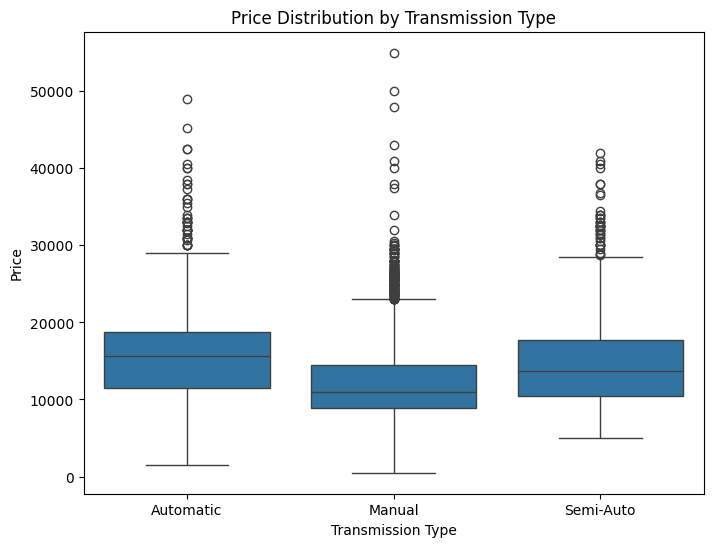

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create the box plot
plt.figure(figsize=(8,6))
sns.boxplot(x="transmission", y="price", data=df)

plt.title("Price Distribution by Transmission Type")
plt.xlabel("Transmission Type")
plt.ylabel("Price")
plt.show()


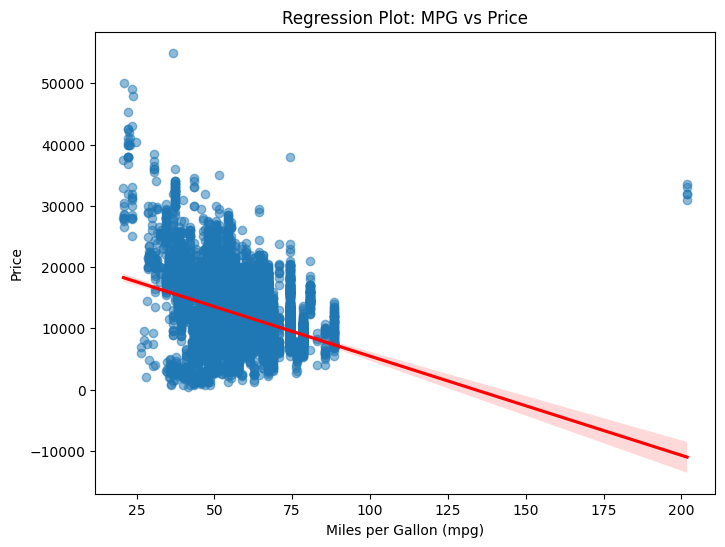

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create regression plot
plt.figure(figsize=(8,6))
sns.regplot(x="mpg", y="price", data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Regression Plot: MPG vs Price")
plt.xlabel("Miles per Gallon (mpg)")
plt.ylabel("Price")
plt.show()


In [25]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['mpg']]   # mpg as predictor
y = df['price']   # price as target

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Calculate R² and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² value:", r2)
print("Mean Squared Error:", mse)


R² value: 0.1504343741072478
Mean Squared Error: 19049855.140110757


In [26]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Calculate R² and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² value:", r2)
print("Mean Squared Error:", mse)

R² value: 0.6917125923771564
Mean Squared Error: 6912744.910746688


In [27]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create pipeline: StandardScaler -> PolynomialFeatures (degree=2) -> LinearRegression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

# Fit the pipeline model
pipeline.fit(X_train, y_train)

# Predict on test set
y_pred = pipeline.predict(X_test)

# Calculate R² and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² value:", r2)
print("Mean Squared Error:", mse)

R² value: 0.12122807147172776
Mean Squared Error: 19704749.61491985


In [28]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)

# Predict on test set
y_pred = ridge_model.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)

print("R² value:", r2)

R² value: 0.6917134446113138


In [29]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply second-order polynomial transform
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Create and fit Ridge regression model with alpha=0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_poly, y_train)

# Predict on test set
y_pred = ridge_model.predict(X_test_poly)

# Calculate R² and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² value:", r2)
print("Mean Squared Error:", mse)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.1777e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


R² value: 0.673274888823681
Mean Squared Error: 7326174.5165419085


In [30]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
X = df[['year', 'mileage', 'tax', 'mpg', 'engineSize']]
y = df['price']

# Split into training and testing sets (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply second-order polynomial transform
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Define Ridge regression and parameter grid
ridge = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Grid Search with 4-fold cross validation
grid_search = GridSearchCV(ridge, param_grid, cv=4, scoring='r2')
grid_search.fit(X_train_poly, y_train)

# Best alpha
best_alpha = grid_search.best_params_['alpha']
print("Best alpha:", best_alpha)

# Fit Ridge with best alpha
best_ridge = Ridge(alpha=best_alpha)
best_ridge.fit(X_train_poly, y_train)

# Predict on test set
y_pred = best_ridge.predict(X_test_poly)

# Calculate R² and MSE
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R² value:", r2)
print("Mean Squared Error:", mse)

/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.0567e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.98143e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=3.10209e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.85743e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.9414e-24): resul

Best alpha: 0.01


/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=2.27922e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


R² value: 0.38273414165699104
Mean Squared Error: 13840985.11755802


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

# Features
numeric_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
categorical_features = ['model', 'transmission', 'fuelType']

# Split data
X = df[numeric_features + categorical_features]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
numeric_transformer = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Full pipeline with Ridge regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

# Grid search for alpha
param_grid = {'ridge__alpha': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(pipeline, param_grid, cv=4, scoring='r2')
grid_search.fit(X_train, y_train)

# Best model
best_alpha = grid_search.best_params_['ridge__alpha']
y_pred = grid_search.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Best alpha:", best_alpha)
print("R² value:", r2)
print("Mean Squared Error:", mse)

Best alpha: 1
R² value: 0.4058336336691005
Mean Squared Error: 13323023.981620558


[Abhishek Gagneja](https://www.linkedin.com/in/abhishek-gagneja-23051987/)


## Change Log


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-12-10|0.1|Abhishek Gagneja|Initial Draft created|


Copyright © 2023 IBM Corporation. All rights reserved.
